# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 25     |  |
| :-------------|:-------------|
| Kimi Hekmat | 6534759 |
| Sebas van den Akker | 6562892 |
| Max Feijtes| 6498396|
| Planning Groep: 25     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | 12:30 |
| Mijlpaal 2 | 17:00 |
| groep aanwezig 1| 10:40 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 17:00-17:15 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np

def berekenCapaciteitVakkePlaat(d, A, epsilon):
    output = epsilon * A / d
    return output

def berekenCapaciteit(V_out_max, V_in_max, R, f):
    output = V_out_max/(R*V_in_max*2*np.pi*f) 
    return output

def Vout_uit_cap(C, V_in_max, R, f):
    return C*R*V_in_max*2*np.pi*f

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

# In onze schets gebruiken we als isolerend materiaal karton, met een epsilon van 2.5*e0. Het karton gaat 2.2 mm dit zijn

# Verwachte capaciteit:
C = berekenCapaciteitVakkePlaat(0.0022, 0.1**2, (2.5 * 8.854E-12))*1e12


print(f"Berekende capaciteit plaatcondensator groep 25 is {C:.1f} pF")



Berekende capaciteit plaatcondensator groep 25 is 100.6 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](scope.jpeg)
![scope meting 2](sensor.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 25|  100,6 pF | 0,498 V | 0,4687 V | 93,9 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schetsen.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die massa meet (een weegschaal). Dit gaat door de verandering van $d$

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uitgewerkteschets.jpeg)

We moeten weten hoe de massa de capaciteit beinvloedt. We weten al dat de massa zal zorgen voor een kleinere onderlinge afstand d, en we weten dat d en C omgekeerd evenredig zijn (zie formule eerder gedefinieerd).

Dan moeten we wel nog weten wat het verband precies is tussen de massa en de onderlinge afstand d. Hiervoor wordt de aanname gebruikt dat we te maken hebben met een lineair elastisch materiaal. De elasticiteitsmodulus is hiervoor

$E = \frac{\sigma}{\epsilon}$


$ \sigma = \frac{F}{A}$ en $\epsilon = \frac{\Delta d}{d}$
met $F = ma$

Gecombineerd:
$ \epsilon = \frac{F}{A*E} = \frac{\Delta d}{d}$

Hieruit volgt dus dat d omgekeerd evenredig is met de kracht, en dus omgekeerd evenredig met m.
d was ook omgekeerd evenredig met de capaciteit, dus m is als het goed is, binnen de aannames, evenredig met de capaciteit. Vandaar gaan we voor onze kalibratiegrafiek een lijn fitten. We kunnen hier niet een reele functie van maken omdat we E niet weten, maar een lineaire fit zou genoeg fysische onderbouwing moeten geven.


C:\Users\kimiy\AppData\Local\Temp\ipykernel_30224\2325879596.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  vals, covs = curve_fit(fitverw, m_verw, Cap_verw)


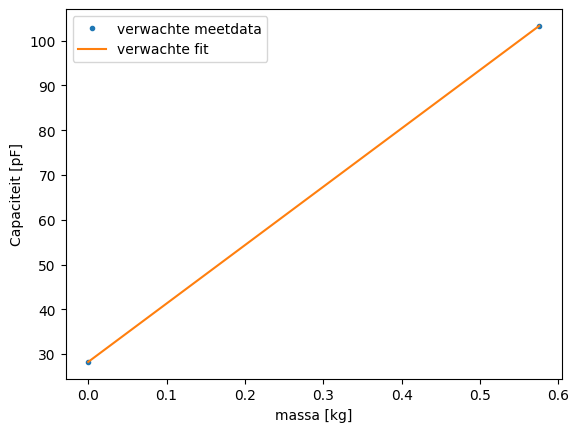

De minimum, gemiddelde, en maximum waarde binnen ons verwachte domein gaan zijn 28.25, 65.77, 103.3 pF (voor LTspice)


In [3]:
# Om de kalibratiegrafiek te maken gebruiken we de beredenering hierboven, daarom meten we 2 punten en trekken we daar een lijn doorheen. Dit wordt onze kalibratiegrafiek

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# We nemen geen massa en de massa van een iphone
m_verw = np.array([0, 575.4])*1e-3

# We meten dan de V_max_out
V_max_out_verw = np.array([134e-3, 490e-3])
Cap_verw = berekenCapaciteit(V_max_out_verw, 7.55, 1000, 100000)*1e12

def fitverw(x, a, b):
    return a*x + b

vals, covs = curve_fit(fitverw, m_verw, Cap_verw)
xtest = np.linspace(np.min(m_verw), np.max(m_verw), 500)
ytest = fitverw(xtest, *vals,)

plt.figure()
plt.plot(m_verw, Cap_verw, '.', label = 'verwachte meetdata')
plt.plot(xtest, ytest, '-', label = 'verwachte fit')
plt.xlabel('massa [kg]')
plt.ylabel("Capaciteit [pF]")
plt.legend()
plt.show()

min = np.min(ytest)
mean = np.mean(ytest)
max = np.max(ytest)

print(f"De minimum, gemiddelde, en maximum waarde binnen ons verwachte domein gaan zijn {min:.4g}, {mean:.4g}, {max:.4g} pF (voor LTspice)")

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 28.25 |141.58099 |
| gemiddelde capaciteit| 65.77 |330.28528 |
| maximale capaciteit| 103.3 |517.91584 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
Meting 1: We meten eerst de capaciteit zonder massa op de plaat
![meting 1](metingm0.jpeg)
![meting 1](scopem0.jpeg)

Meting 2: We meten daarna de capaciteit met de fles maximaal gevuld (575 gram), daarna zullen we water weggooien om zo binnen het bereik meer meetpunten te krijgen.
![meting 1](metingmmax.jpeg)
![meting 1](scope_metfles.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

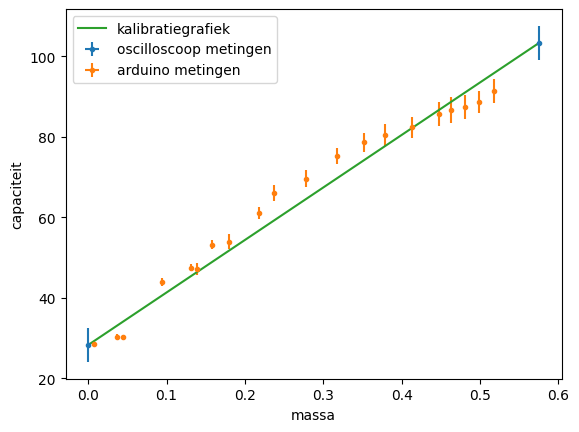

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

# Eerst de metingen die we zelf met de osciloscoop doen

# We nemen geen massa en de massa van een volle fles
m_verw = np.array([0, 575.4])*1e-3

# We meten dan de V_max_out en berekenen capaciteit
V_max_out_verw = np.array([134e-3, 490e-3])
Cap_verw = berekenCapaciteit(V_max_out_verw, 7.55, 1000, 100000)*1e12

# Hier berekenen we de error in de capaciteit met calculus approach. We schatten de onzekerheid van de weerstand en frequentie op 0 en schatten de onzekerheden van Vin en Vuit
def error_oscilooscop(Vout, uVout, Vin, uVin, Cap):
    return np.sqrt((uVout/Vout)**2 + (uVin/Vin)**2)*Cap
u_C_osc = error_oscilooscop(V_max_out_verw, 20e-3, 7.94, 0.01, Cap_verw)

# Nu door met arduino, hier de metingen
m = np.array([518.5, 498.7, 481.1, 462.7,447.4, 413.4, 378.6, 352.4, 317.2, 277.6, 236.9, 217.7, 180.0, 158.5, 138.6, 131.2, 94.6, 43.8, 36.6, 7.0])*1e-3 # kg
capaciteit = np.array([91.4, 88.6, 87.4, 86.6, 85.6, 82.3, 80.4, 78.6, 75.2, 69.6, 66.0, 61.0, 53.9, 53.2, 47.2, 47.4, 43.9, 30.2, 30.3, 28.4]) # pF

# Tijdens het meten fluctueerde de arduino waarde, hier onzekerheid geschat
u_cap = np.array([3.0,2.7,3.0,3.3,3.0,2.7,2.7,2.4,2.1,2.1,2.1,1.5,1.8,1.2,1.5,0.9,0.9,0.6,0.6,0.3])

# Geschat op basis van de waarde die we van de weegschaal aflezen
m_err = 0.05 * 1e-3

plt.figure()
plt.errorbar(m_verw , Cap_verw, xerr = m_err, yerr = u_C_osc, fmt= '.', label = 'oscilloscoop metingen')
plt.errorbar(m, capaciteit, xerr = m_err, yerr = u_cap, fmt = '.', label = 'arduino metingen')
plt.plot(xtest, ytest, '-', label = 'kalibratiegrafiek')
plt.xlabel("massa")
plt.ylabel("capaciteit")
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

De metingen komen niet overeen met de geschatte kalibratiegrafiek, want de punten wijken op vele plekken duidelijk af en de errorbars gaan ook niet allemaal door de kalibratiegrafiek heen. Een paar mogelijke verbeteringen:

* De opstelling vasttapen aan het bord zodat we invloed van verschuiving minimaliseren
* We kunnen ook een dikker laag schuim gebruiken, dan zal een verschil in gewicht een groter verschil in dikte geven waardoor de capaciteit misschien nauwkeuriger te bepalen is.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
We hebben hier alles netjes vastgetapet, en dikkere schuin gebruikt
![foto sensor](uiteindelijkegrafiek.jpeg)

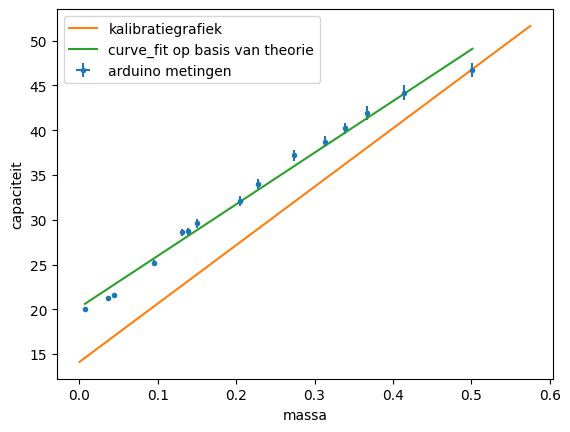

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

m_2 = np.array([501.5, 414.4,367.5, 338.6, 313.2, 274.4, 228.1, 205.0, 150.0, 138.7, 131.2, 94.6, 43.8, 36.6, 7.0])/1000 # kg
capaciteit_2 = np.array([46.7, 44.2, 41.9, 40.2, 38.7, 37.2, 34.0, 32.1, 29.6, 28.7, 28.6, 25.2, 21.6, 21.3, 20.0]) # pF
u_capa_2 = np.array([0.8, 0.8, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.5, 0.4, 0.4, 0.3, 0.2, 0.2, 0.2]) # pF
# plt.plot(m_2, capaciteit_2, ".")

#Fit van onze waardes, op basis van lineaire verband dat beredeneerd was:
vals2, covs2 = curve_fit(fitverw, m_2, capaciteit_2)
xfit = np.linspace(np.min(m_2), np.max(m_2), 500)
yfit = fitverw(xfit, *vals2)

plt.figure()
plt.errorbar(m_2, capaciteit_2, xerr = m_err, yerr = u_capa_2, fmt = '.', label = 'arduino metingen')
plt.plot(xtest, ytest/2, '-', label = 'kalibratiegrafiek')  #ytest/2 omdat we de dikte van het verende materiaal verdubbeld hebben waardoor de veerconstante effectief verdubbeld. *1/2 is een correctie.
plt.plot(xfit, yfit, label = 'curve_fit op basis van theorie')
plt.xlabel("massa")
plt.ylabel("capaciteit")
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

Onze sensor was na iteratie geschikt om massa te meten. De iteratie leverde namelijk een voldoende verbetering op ons eerste ontwerp. Er zit wel een redelijk significante afwijking van onze ontwerpgrafiek, maar dat was grotendeels omdat de ontwerpgrafiek was gebasseerd op de opstelling van voor de iteratie. De twee grafieken waren echter wel van dezelfde lineaire vorm die we afgeleid hadden. De vlakke plaatformule voldeed voor de rest prachtig aan onze sensor.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

LEERDOEL 1

In [6]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np

def berekenCapaciteitVakkePlaat(d, A, epsilon):
    output = epsilon * A / d
    return output

def berekenCapaciteit(V_out_max, V_in_max, R, f):
    output = V_out_max/(R*V_in_max*2*np.pi*f) 
    return output

def Vout_uit_cap(C, V_in_max, R, f):
    return C*R*V_in_max*2*np.pi*f

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

Ontwerpproces en het meten van de fysische grootheid

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uitgewerkteschets.jpeg)

Meting 2: We meten daarna de capaciteit met de fles maximaal gevuld (575 gram), daarna zullen we water weggooien om zo binnen het bereik meer meetpunten te krijgen.
![meting 1](metingmmax.jpeg)
![meting 1](scope_metfles.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

In [7]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np

def berekenCapaciteitVakkePlaat(d, A, epsilon):
    output = epsilon * A / d
    return output

def berekenCapaciteit(V_out_max, V_in_max, R, f):
    output = V_out_max/(R*V_in_max*2*np.pi*f) 
    return output

def Vout_uit_cap(C, V_in_max, R, f):
    return C*R*V_in_max*2*np.pi*f

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

#### Voeg hier de foto's van je sensoren in actie in.
Meting 1: We meten eerst de capaciteit zonder massa op de plaat
![meting 1](metingm0.jpeg)
![meting 1](scopem0.jpeg)

We moeten weten hoe de massa de capaciteit beinvloedt. We weten al dat de massa zal zorgen voor een kleinere onderlinge afstand d, en we weten dat d en C omgekeerd evenredig zijn (zie formule eerder gedefinieerd).

Dan moeten we wel nog weten wat het verband precies is tussen de massa en de onderlinge afstand d. Hiervoor wordt de aanname gebruikt dat we te maken hebben met een lineair elastisch materiaal. De elasticiteitsmodulus is hiervoor

$E = \frac{\sigma}{\epsilon}$


$ \sigma = \frac{F}{A}$ en $\epsilon = \frac{\Delta d}{d}$
met $F = ma$

Gecombineerd:
$ \epsilon = \frac{F}{A*E} = \frac{\Delta d}{d}$

Hieruit volgt dus dat d omgekeerd evenredig is met de kracht, en dus omgekeerd evenredig met m.
d was ook omgekeerd evenredig met de capaciteit, dus m is als het goed is, binnen de aannames, evenredig met de capaciteit. Vandaar gaan we voor onze kalibratiegrafiek een lijn fitten. We kunnen hier niet een reele functie van maken omdat we E niet weten, maar een lineaire fit zou genoeg fysische onderbouwing moeten geven.


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

C:\Users\kimiy\AppData\Local\Temp\ipykernel_30224\2325879596.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  vals, covs = curve_fit(fitverw, m_verw, Cap_verw)


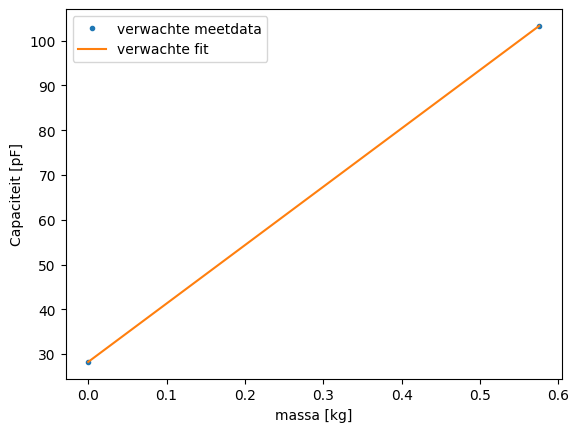

De minimum, gemiddelde, en maximum waarde binnen ons verwachte domein gaan zijn 28.25, 65.77, 103.3 pF (voor LTspice)


In [8]:
# Om de kalibratiegrafiek te maken gebruiken we de beredenering hierboven, daarom meten we 2 punten en trekken we daar een lijn doorheen. Dit wordt onze kalibratiegrafiek

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# We nemen geen massa en de massa van een iphone
m_verw = np.array([0, 575.4])*1e-3

# We meten dan de V_max_out
V_max_out_verw = np.array([134e-3, 490e-3])
Cap_verw = berekenCapaciteit(V_max_out_verw, 7.55, 1000, 100000)*1e12

def fitverw(x, a, b):
    return a*x + b

vals, covs = curve_fit(fitverw, m_verw, Cap_verw)
xtest = np.linspace(np.min(m_verw), np.max(m_verw), 500)
ytest = fitverw(xtest, *vals,)

plt.figure()
plt.plot(m_verw, Cap_verw, '.', label = 'verwachte meetdata')
plt.plot(xtest, ytest, '-', label = 'verwachte fit')
plt.xlabel('massa [kg]')
plt.ylabel("Capaciteit [pF]")
plt.legend()
plt.show()

min = np.min(ytest)
mean = np.mean(ytest)
max = np.max(ytest)

print(f"De minimum, gemiddelde, en maximum waarde binnen ons verwachte domein gaan zijn {min:.4g}, {mean:.4g}, {max:.4g} pF (voor LTspice)")

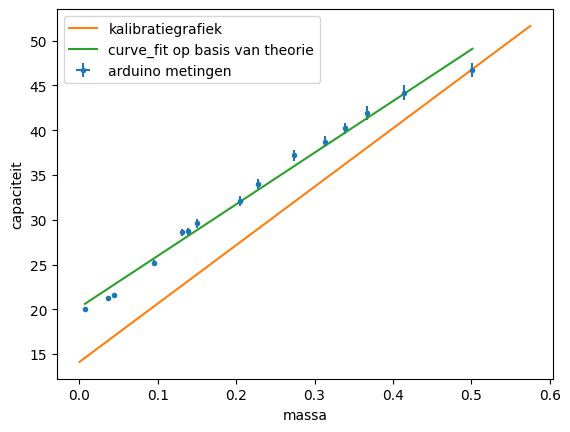

In [9]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

m_2 = np.array([501.5, 414.4,367.5, 338.6, 313.2, 274.4, 228.1, 205.0, 150.0, 138.7, 131.2, 94.6, 43.8, 36.6, 7.0])/1000 # kg
capaciteit_2 = np.array([46.7, 44.2, 41.9, 40.2, 38.7, 37.2, 34.0, 32.1, 29.6, 28.7, 28.6, 25.2, 21.6, 21.3, 20.0]) # pF
u_capa_2 = np.array([0.8, 0.8, 0.8, 0.6, 0.6, 0.6, 0.6, 0.6, 0.5, 0.4, 0.4, 0.3, 0.2, 0.2, 0.2]) # pF
# plt.plot(m_2, capaciteit_2, ".")

#Fit van onze waardes, op basis van lineaire verband dat beredeneerd was:
vals2, covs2 = curve_fit(fitverw, m_2, capaciteit_2)
xfit = np.linspace(np.min(m_2), np.max(m_2), 500)
yfit = fitverw(xfit, *vals2)

plt.figure()
plt.errorbar(m_2, capaciteit_2, xerr = m_err, yerr = u_capa_2, fmt = '.', label = 'arduino metingen')
plt.plot(xtest, ytest/2, '-', label = 'kalibratiegrafiek')  #ytest/2 omdat we de dikte van het verende materiaal verdubbeld hebben waardoor de veerconstante effectief verdubbeld. *1/2 is een correctie.
plt.plot(xfit, yfit, label = 'curve_fit op basis van theorie')
plt.xlabel("massa")
plt.ylabel("capaciteit")
plt.legend()
plt.show()

Conclusie:

Onze sensor was na iteratie geschikt om massa te meten. De iteratie leverde namelijk een voldoende verbetering op ons eerste ontwerp. Er zit wel een redelijk significante afwijking van onze ontwerpgrafiek, maar dat was grotendeels omdat de ontwerpgrafiek was gebasseerd op de opstelling van voor de iteratie. De twee grafieken waren echter wel van dezelfde lineaire vorm die we afgeleid hadden. De vlakke plaatformule voldeed voor de rest prachtig aan onze sensor.